# Projeto: BBC News Archive
* Objetivo: Classificar notícias.
  
**Texto Kaggle:**

**a) Context**
News article datasets, originating from BBC News, provided for use as benchmarks for machine learning research. The original data is processed to form a single csv file for ease of use, the news title and the related text file name is preserved along with the news content and its category. This dataset is made available for non-commercial and research purposes only.

All rights, including copyright, in the content of the original articles are owned by the BBC.

**b) Content**
Consists of 2225 documents from the BBC news website corresponding to stories in five topical areas from 2004-2005.
Class Labels: 5 (business, entertainment, politics, sport, tech)

**c) Acknowledgements**
The original source of the data may be accessed through this link and it might be interesting to read the associated research article.

Associated Official Research Papers
D. Greene and P. Cunningham. "Practical Solutions to the Problem of Diagonal Dominance in Kernel Document Clustering", Proc. ICML 2006.

**d) Inspiration**
Text Classification

In [34]:
import pandas as pd
bbc = pd.read_csv("bbc-news-data.csv",sep='\t', #arquivo dividido por \t          
    quotechar='"', #evitar gerar colunas extras, pois há vírgulas nos textos
    on_bad_lines='skip') #eliminar linhas corrompidas
bbc.head()

,category,filename,title,content
0,business,001.txt,Ad sales boost Time Warner profit,Quarterly profits at US media giant TimeWarne...
1,business,002.txt,Dollar gains on Greenspan speech,The dollar has hit its highest level against ...
2,business,003.txt,Yukos unit buyer faces loan claim,The owners of embattled Russian oil giant Yuk...
3,business,004.txt,High fuel prices hit BA's profits,British Airways has blamed high fuel prices f...
4,business,005.txt,Pernod takeover talk lifts Domecq,Shares in UK drinks and food firm Allied Dome...


In [2]:
bbc.tail()

,category,filename,title,content
2220,tech,397.txt,BT program to beat dialler scams,BT is introducing two initiatives to help bea...
2221,tech,398.txt,Spam e-mails tempt net shoppers,Computer users across the world continue to i...
2222,tech,399.txt,Be careful how you code,A new European directive could put software w...
2223,tech,400.txt,US cyber security chief resigns,The man making sure US computer networks are ...
2224,tech,401.txt,Losing yourself in online gaming,"Online role playing games are time-consuming,..."


In [8]:
# Checagem do dataset
bbc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2225 entries, 0 to 2224
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   category  2225 non-null   object
 1   filename  2225 non-null   object
 2   title     2225 non-null   object
 3   content   2225 non-null   object
dtypes: object(4)
memory usage: 69.7+ KB


In [11]:
# Verificar as categorias
bbc["category"].unique()

array(['business', 'entertainment', 'politics', 'sport', 'tech'],
      dtype=object)

# Parte 1: Abordagem clássica

## Pré-processamento (Visando abordagens clássicas)
* Ideia: o texto precisa virar uma representação numérica relativamente simples.

In [6]:
import re
import nltk
import spacy
from nltk.corpus import stopwords

nltk.download('stopwords') #reconhecer as palavras muito frequentes, mas pouco informativas, ex: the
nlp = spacy.load("en_core_web_sm")
stop_words = set(stopwords.words('english')) #Cria um conjunto com as stopwords em inglês.
# set é importante porque a busca fica mais rápida do que em lista.

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\leomi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [12]:
# Limpeza
def clean_text(text): #Buscar padronização
    text = text.lower() # Para Government e government serem a mesma coisa por exemplo.
    text = re.sub(r'\n', ' ', text) #Quebras de linha são transformadas em espaço
    text = re.sub(r'\r', ' ', text)
    #text = re.sub(r'[^a-zA-Z\s]', '', text)  # remove pontuação/números
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text) #Mantém números que são importantes para textos de economia
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [13]:
# Remoção de Stopwords
def remove_stopwords(text):
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

In [14]:
#Lematização
def lemmatize(text):
    doc = nlp(text)
    return " ".join([token.lemma_ for token in doc])

In [35]:
# Criando outras colunas para comparação de modelos
bbc['text_clean'] = bbc['content'].apply(clean_text) #padronizado
bbc['text_no_stop'] = bbc['text_clean'].apply(remove_stopwords) #sem stopwords
bbc['text_lemma'] = bbc['text_no_stop'].apply(lemmatize) #lematização

  

In [33]:
#Exemplos
print("Original:", bbc['content'][0])
print("------\n")
print("Processed:", bbc['text_lemma'][0])

Original:  Quarterly profits at US media giant TimeWarner jumped 76% to $1.13bn (£600m) for the three months to December, from $639m year-earlier.  The firm, which is now one of the biggest investors in Google, benefited from sales of high-speed internet connections and higher advert sales. TimeWarner said fourth quarter sales rose 2% to $11.1bn from $10.9bn. Its profits were buoyed by one-off gains which offset a profit dip at Warner Bros, and less users for AOL.  Time Warner said on Friday that it now owns 8% of search-engine Google. But its own internet business, AOL, had has mixed fortunes. It lost 464,000 subscribers in the fourth quarter profits were lower than in the preceding three quarters. However, the company said AOL's underlying profit before exceptional items rose 8% on the back of stronger internet advertising revenues. It hopes to increase subscribers by offering the online service free to TimeWarner internet customers and will try to sign up AOL's existing customers fo

* **Comentário:** Com isso poderemos responder Stopwords ajudam ou atrapalham? Lemmatization melhora? Remover pontuação faz diferença?

## Vetorização: Representação de texto por vetores

### Abordagens
#### i) Bag of Words
* Representar texto como contagem de palavras, ignorando: ordem; contexto; gramática

#### ii) TF-IDF (Term Frequency - Inverse Document Frequency)
* Problema do BoW: Palavras muito frequentes aparecem muito, exemplo “the” e “is”, mas não ajudam a distinguir classes.
* TF-IDF: Dar mais peso para palavras frequentes no documento e raras no conjunto de documentos

In [36]:
bbc.head()

,category,filename,title,content,text_clean,text_no_stop,text_lemma
0,business,001.txt,Ad sales boost Time Warner profit,Quarterly profits at US media giant TimeWarne...,quarterly profits at us media giant timewarner...,quarterly profits us media giant timewarner ju...,quarterly profit us medium giant timewarner ju...
1,business,002.txt,Dollar gains on Greenspan speech,The dollar has hit its highest level against ...,the dollar has hit its highest level against t...,dollar hit highest level euro almost three mon...,dollar hit high level euro almost three month ...
2,business,003.txt,Yukos unit buyer faces loan claim,The owners of embattled Russian oil giant Yuk...,the owners of embattled russian oil giant yuko...,owners embattled russian oil giant yukos ask b...,owner embattle russian oil giant yukos ask buy...
3,business,004.txt,High fuel prices hit BA's profits,British Airways has blamed high fuel prices f...,british airways has blamed high fuel prices fo...,british airways blamed high fuel prices 40 dro...,british airways blame high fuel price 40 drop ...
4,business,005.txt,Pernod takeover talk lifts Domecq,Shares in UK drinks and food firm Allied Dome...,shares in uk drinks and food firm allied domec...,shares uk drinks food firm allied domecq risen...,share uk drink food firm ally domecq rise spec...


In [37]:
bbc.columns

Index(['category', 'filename', 'title', 'content', 'text_clean',
       'text_no_stop', 'text_lemma'],
      dtype='object')

In [42]:
from sklearn.model_selection import train_test_split

y = bbc["category"]

train_idx, test_idx = train_test_split(
    bbc.index,
    test_size=0.2,
    stratify=y
)

In [43]:
# Versões
text_versions = {
    "raw": "content",
    "clean": "text_clean", #Limpo, mas com stopwords
    "no_stop": "text_no_stop",
    "lemma": "text_lemma"
}

In [44]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

vectorized_data = {}

for version_name, column_name in text_versions.items():
    X_train_text = bbc.loc[train_idx, column_name]
    X_test_text = bbc.loc[test_idx, column_name]
    
    # BoW
    bow_vectorizer = CountVectorizer()
    X_train_bow = bow_vectorizer.fit_transform(X_train_text)
    X_test_bow = bow_vectorizer.transform(X_test_text)
    
    # TF-IDF
    tfidf_vectorizer = TfidfVectorizer()
    X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_text)
    X_test_tfidf = tfidf_vectorizer.transform(X_test_text)
    
    vectorized_data[version_name] = {
        "bow": {
            "X_train": X_train_bow,
            "X_test": X_test_bow,
            "vectorizer": bow_vectorizer
        },
        "tfidf": {
            "X_train": X_train_tfidf,
            "X_test": X_test_tfidf,
            "vectorizer": tfidf_vectorizer
        }
    }

## 3) Modelagem

1. pré-processamento
    * raw
    * clean
    * no_stop
    * lemma

2. representação
    * BoW
    * TF-IDF

3. modelo
    * Logistic Regression
    * Linear SVM
    * talvez Multinomial Naive Bayes

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import accuracy_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

In [58]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=2000, random_state=42),
    "LinearSVC": LinearSVC(random_state=42),
    "MultinomialNB": MultinomialNB()
}

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []

for version_name in vectorized_data:
    for repr_name in vectorized_data[version_name]:
        X_train = vectorized_data[version_name][repr_name]["X_train"]
        X_test = vectorized_data[version_name][repr_name]["X_test"]

        for model_name, base_model in models.items():
            model = clone(base_model)

            # Validação cruzada no conjunto de treino
            cv_scores = cross_validate(
                model,
                X_train,
                y_train,
                cv=cv,
                scoring={
                    "accuracy": "accuracy",
                    "f1_macro": "f1_macro"
                },
                n_jobs=-1,
                return_train_score=False
            )

            # Ajuste final no treino completo
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            results.append({
                "preprocessing": version_name,
                "representation": repr_name,
                "model": model_name,

                "cv_accuracy_mean": np.mean(cv_scores["test_accuracy"]),
                "cv_accuracy_std": np.std(cv_scores["test_accuracy"]),

                "cv_f1_mean": np.mean(cv_scores["test_f1_macro"]),
                "cv_f1_std": np.std(cv_scores["test_f1_macro"]),

                "test_accuracy": accuracy_score(y_test, y_pred),
                "test_f1_macro": f1_score(y_test, y_pred, average="macro")
            })

In [60]:
# Tabela
results_df = pd.DataFrame(results).sort_values(
    by=["cv_f1_mean", "test_f1_macro"],
    ascending=False
)

print(results_df)

   preprocessing representation               model  cv_accuracy_mean  \
16       no_stop          tfidf           LinearSVC          0.980337   
22         lemma          tfidf           LinearSVC          0.978090   
4            raw          tfidf           LinearSVC          0.977528   
10         clean          tfidf           LinearSVC          0.976966   
14       no_stop            bow       MultinomialNB          0.975281   
13       no_stop            bow           LinearSVC          0.974157   
15       no_stop          tfidf  LogisticRegression          0.973034   
2            raw            bow       MultinomialNB          0.971910   
21         lemma          tfidf  LogisticRegression          0.971348   
12       no_stop            bow  LogisticRegression          0.970787   
19         lemma            bow           LinearSVC          0.970225   
3            raw          tfidf  LogisticRegression          0.970225   
20         lemma            bow       MultinomialNB

In [62]:
# Melhor por modelo
best_per_model = results_df.loc[
    results_df.groupby("model")["cv_f1_mean"].idxmax()
].sort_values("cv_f1_mean", ascending=False)

print("\nMelhor configuração de cada modelo:")
print(best_per_model)

#Melhor geral
best_per_model = results_df.loc[
    results_df.groupby("model")["cv_f1_mean"].idxmax()
].sort_values("cv_f1_mean", ascending=False)

print("\nMelhor configuração de cada modelo:")
print(best_per_model)


Melhor configuração de cada modelo:
   preprocessing representation               model  cv_accuracy_mean  cv_accuracy_std  cv_f1_mean  cv_f1_std  test_accuracy  test_f1_macro
16       no_stop          tfidf           LinearSVC          0.980337         0.006647    0.980414   0.006810       0.979775       0.979158
14       no_stop            bow       MultinomialNB          0.975281         0.004494    0.974458   0.004708       0.977528       0.976457
15       no_stop          tfidf  LogisticRegression          0.973034         0.008063    0.973022   0.007931       0.979775       0.979465

Melhor configuração de cada modelo:
   preprocessing representation               model  cv_accuracy_mean  cv_accuracy_std  cv_f1_mean  cv_f1_std  test_accuracy  test_f1_macro
16       no_stop          tfidf           LinearSVC          0.980337         0.006647    0.980414   0.006810       0.979775       0.979158
14       no_stop            bow       MultinomialNB          0.975281         0.004494

#### Gráfico

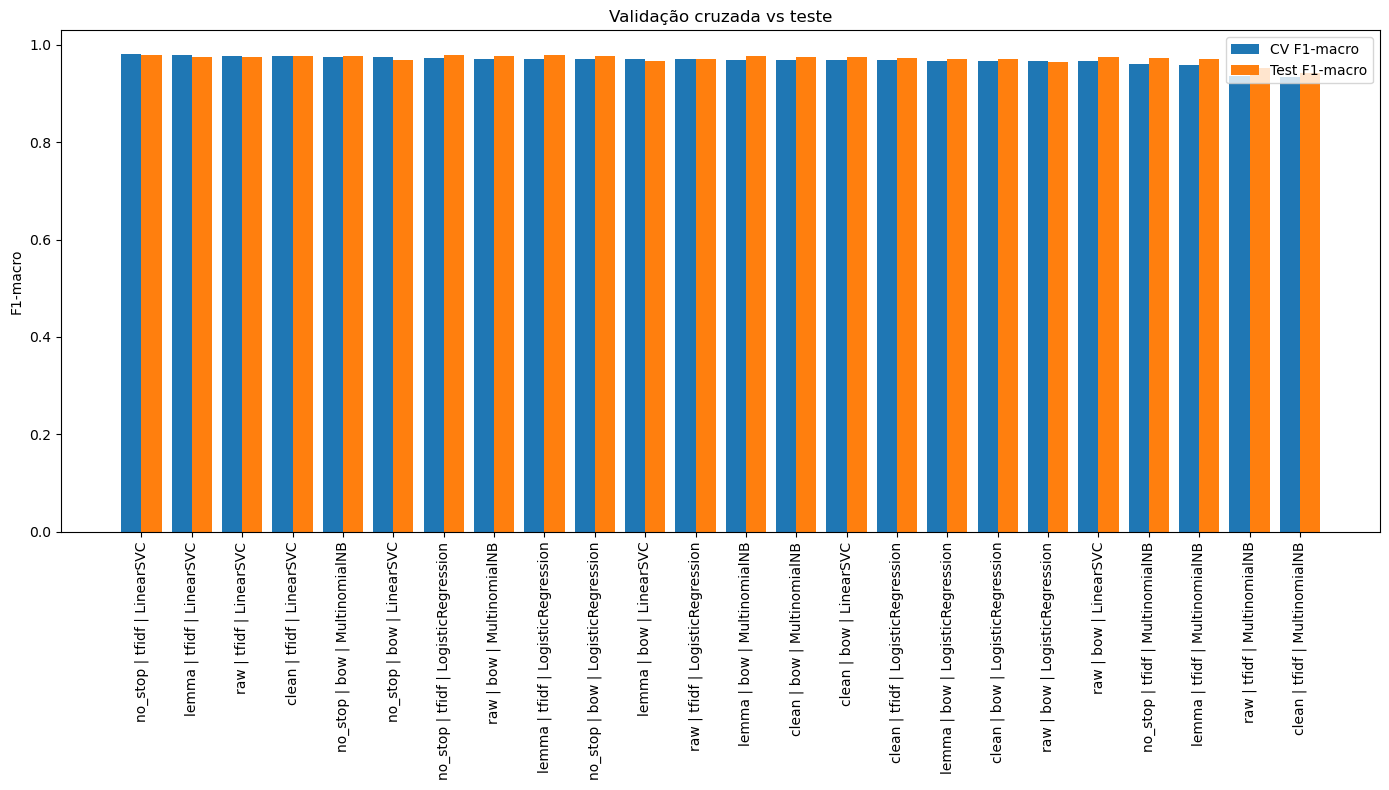

In [68]:
#CV vs Teste
plot_df = results_df.copy()
plot_df["config"] = (
    plot_df["preprocessing"] + " | " +
    plot_df["representation"] + " | " +
    plot_df["model"]
)

x = np.arange(len(plot_df))
width = 0.4

plt.figure(figsize=(14, 8))
plt.bar(x - width/2, plot_df["cv_f1_mean"], width, label="CV F1-macro")
plt.bar(x + width/2, plot_df["test_f1_macro"], width, label="Test F1-macro")

plt.xticks(x, plot_df["config"], rotation=90)
plt.ylabel("F1-macro")
plt.title("Validação cruzada vs teste")
plt.legend()
plt.tight_layout()
plt.show()

representation       bow     tfidf
preprocessing                     
clean           0.966060  0.968483
lemma           0.966419  0.971084
no_stop         0.970260  0.973022
raw             0.965973  0.969671


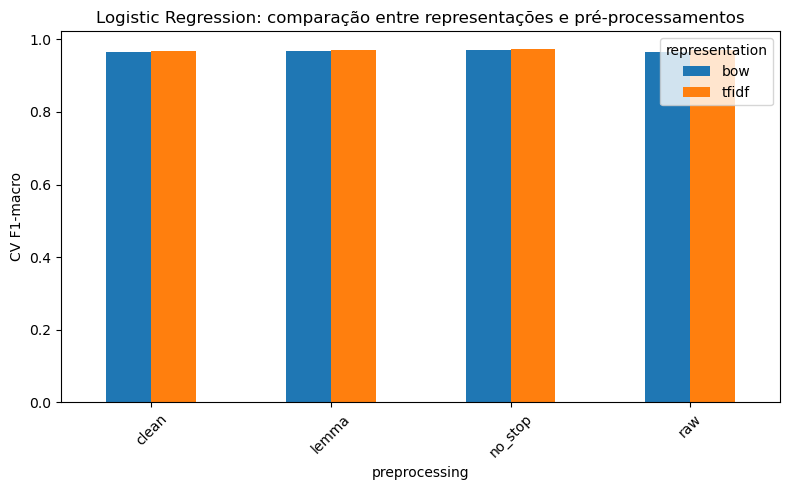

In [69]:
# pivô por pré-processamento e representação para um modelo específico
logreg_df = results_df[results_df["model"] == "LogisticRegression"]

pivot_logreg = logreg_df.pivot(
    index="preprocessing",
    columns="representation",
    values="cv_f1_mean"
)

print(pivot_logreg)

pivot_logreg.plot(kind="bar", figsize=(8, 5))
plt.ylabel("CV F1-macro")
plt.title("Logistic Regression: comparação entre representações e pré-processamentos")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Melhor modelo
* Critério principal: Escolher o modelo com maior cv_f1_mean
* Critério de desempate: Entre resultados muito próximos (menor cv_f1_std e maior test_f1_macro)

In [63]:
results_ranked = results_df.sort_values(
    by=["cv_f1_mean", "cv_f1_std", "test_f1_macro"],
    ascending=[False, True, False]
)

best_model = results_ranked.iloc[0]

print("Melhor configuração segundo CV F1-macro:")
print(best_model)

Melhor configuração segundo CV F1-macro:
preprocessing         no_stop
representation          tfidf
model               LinearSVC
cv_accuracy_mean     0.980337
cv_accuracy_std      0.006647
cv_f1_mean           0.980414
cv_f1_std             0.00681
test_accuracy        0.979775
test_f1_macro        0.979158
Name: 16, dtype: object


In [64]:
best_row = results_df.iloc[0]

print(
    f"O melhor modelo foi {best_row['model']} "
    f"com pré-processamento '{best_row['preprocessing']}' "
    f"e representação '{best_row['representation']}'.\n"
    f"CV F1-macro: {best_row['cv_f1_mean']:.4f} ± {best_row['cv_f1_std']:.4f}\n"
    f"Teste F1-macro: {best_row['test_f1_macro']:.4f}\n"
    f"Teste Accuracy: {best_row['test_accuracy']:.4f}"
)

O melhor modelo foi LinearSVC com pré-processamento 'no_stop' e representação 'tfidf'.
CV F1-macro: 0.9804 ± 0.0068
Teste F1-macro: 0.9792
Teste Accuracy: 0.9798


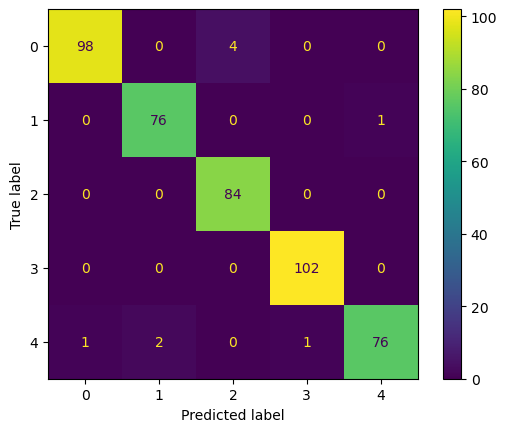

In [65]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

best_model = LinearSVC()
X_train = vectorized_data["no_stop"]["tfidf"]["X_train"]
X_test = vectorized_data["no_stop"]["tfidf"]["X_test"]

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(cm)
disp.plot()

| índice | classe        |
| ------ | ------------- |
| 0      | business      |
| 1      | entertainment |
| 2      | politics      |
| 3      | sport         |
| 4      | tech          |


## Conclusões das abordagens clássicas
* Melhor modelo geral: LinearSVC + no_stop + TF-IDF. Tendo CV F1 ≈ 0.9804 ± 0.0068
* SVM dominou: Top 4 combinações (por CV F1) são todas LinearSVC + TF-IDF.
* TF-IDF foi decisivo, por exemplo, compare:
    * no_stop + bow + LinearSVC → ~0.9737
    * no_stop + tfidf + LinearSVC → ~0.9804
* Stopwords ajudam muito
* Lematização não compensa

# Parte 2: Abordagem Moderna - BERT

* O BERT é um modelo de linguagem que entende palavras no contexto da frase
* **Ideia** do BERT é ler a frase inteira e criar uma representação contextual para cada palavra.
* BERT é baseado em **Transformer (encoder)**

In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from transformers import BertTokenizer, BertForSequenceClassification
from torch.optim import AdamW
from tqdm.auto import tqdm

In [95]:
bbc = bbc.copy()

label_encoder = LabelEncoder()
bbc["label"] = label_encoder.fit_transform(bbc["category"])

print("Classes:", list(label_encoder.classes_))

Classes: ['business', 'entertainment', 'politics', 'sport', 'tech']


In [96]:
#split train/test
train_val_df, test_df = train_test_split(
    bbc[["content", "category", "label"]],
    test_size=0.15,
    stratify=bbc["label"],
    random_state=42
)

train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.1765,  # ~15% do total
    stratify=train_val_df["label"],
    random_state=42
)

print("Treino:", len(train_df))
print("Validação:", len(val_df))
print("Teste:", len(test_df))

Treino: 1557
Validação: 334
Teste: 334


In [97]:
#Tokenizer
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

In [98]:
#Dataset customizado
class BBCDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx])

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(label, dtype=torch.long)
        }

In [99]:
#datasets e dataloader
train_dataset = BBCDataset(train_df["content"], train_df["label"], tokenizer, max_length=256)
val_dataset = BBCDataset(val_df["content"], val_df["label"], tokenizer, max_length=256)
test_dataset = BBCDataset(test_df["content"], test_df["label"], tokenizer, max_length=256)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

In [103]:
# Modelo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando dispositivo:", device)

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=len(label_encoder.classes_)
)
model.to(device)

optimizer = AdamW(model.parameters(), lr=2e-5)

#Avaliação
def evaluate_model(model, dataloader, device):
    model.eval()

    all_preds = []
    all_labels = []
    losses = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            logits = outputs.logits

            preds = torch.argmax(logits, dim=1)

            losses.append(loss.item())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = np.mean(losses)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average="macro")

    return avg_loss, acc, f1, np.array(all_labels), np.array(all_preds)

Usando dispositivo: cpu


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [104]:
# Treino
num_epochs = 3

history = {
    "train_loss": [],
    "val_loss": [],
    "val_accuracy": [],
    "val_f1_macro": []
}

best_val_f1 = -np.inf
best_state_dict = None

for epoch in range(num_epochs):
    model.train()
    train_losses = []

    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")

    for batch in progress_bar:
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())
        progress_bar.set_postfix(loss=loss.item())

    train_loss = np.mean(train_losses)

    val_loss, val_acc, val_f1, _, _ = evaluate_model(model, val_loader, device)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_acc)
    history["val_f1_macro"].append(val_f1)

    print(f"\nEpoch {epoch+1}")
    print(f"Train loss: {train_loss:.4f}")
    print(f"Val loss:   {val_loss:.4f}")
    print(f"Val acc:    {val_acc:.4f}")
    print(f"Val f1:     {val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state_dict = model.state_dict()

Epoch 1/3:   0%|          | 0/195 [00:00<?, ?it/s]


Epoch 1
Train loss: 0.4862
Val loss:   0.0808
Val acc:    0.9790
Val f1:     0.9791


Epoch 2/3:   0%|          | 0/195 [00:00<?, ?it/s]


Epoch 2
Train loss: 0.0815
Val loss:   0.0802
Val acc:    0.9820
Val f1:     0.9818


Epoch 3/3:   0%|          | 0/195 [00:00<?, ?it/s]


Epoch 3
Train loss: 0.0298
Val loss:   0.0628
Val acc:    0.9880
Val f1:     0.9877


In [105]:
# Melhor modelo
if best_state_dict is not None:
    model.load_state_dict(best_state_dict)

In [106]:
# Avaliação
test_loss, test_acc, test_f1, y_test, y_pred = evaluate_model(model, test_loader, device)

print("\nResultados finais no teste:")
print(f"Test loss:     {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test f1_macro: {test_f1:.4f}")


Resultados finais no teste:
Test loss:     0.0434
Test accuracy: 0.9910
Test f1_macro: 0.9909


In [107]:
# Classification report
print("\nClassification report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))


Classification report:
               precision    recall  f1-score   support

     business       0.97      1.00      0.99        76
entertainment       1.00      1.00      1.00        58
     politics       1.00      0.95      0.98        63
        sport       1.00      1.00      1.00        77
         tech       0.98      1.00      0.99        60

     accuracy                           0.99       334
    macro avg       0.99      0.99      0.99       334
 weighted avg       0.99      0.99      0.99       334



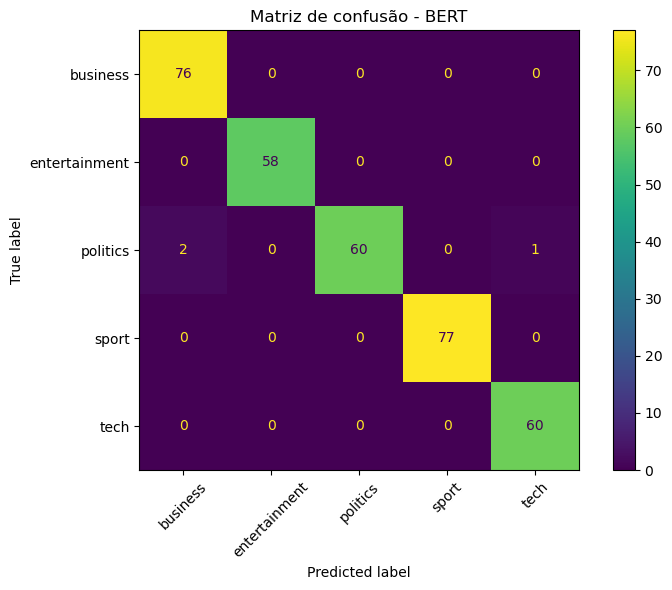

In [108]:
# Matriz confusão
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("Matriz de confusão - BERT")
plt.tight_layout()
plt.show()

### Resultados do BERT
* Excelentes resultados: Accuracy de 0.991 e F1-macro de 0.9909.
* Test loss: 0.0434 $\Rightarrow$ modelo bem calibrado e predições com alta confiança
* Gabaritou entertainment e sports. Em politics teve um recall de 0.95, o que é "esperado", pois política mistura com economia / tecnologia

#### Comparação com abordagem clássica
* Lembrete:
    * LinearSVC + TF-IDF + no_stop $\Rightarrow$ F1 $\approx$ 0.9792
    * BERT $\Rightarrow$ F1 $\approx$ 0.9909
* Ganho de aproximadamente 1.1%
* **Conclusões**:
    * O ganho absoluto foi pequeno (~1%), indicando que o problema já era altamente separável com modelos lineares.
    * BERT teve melhor desempenho em casos ambíguos, por exemplo, política vs economia
    * BERT teve melhor generalização sem ajustes no texto original.
    * Modelos clássicos apresentaram excelente desempenho com menor custo computacional, enquanto o BERT demonstrou maior robustez sem necessidade de engenharia manual de features.